In [1]:
!pip install pandas numpy rapidfuzz missingno matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.2 MB/s eta 0:00:00


Dataset Link:

https://data.cms.gov/provider-data/dataset/mj5m-pzi6?utm_source=chatgpt.com

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from rapidfuzz import fuzz

pd.set_option("display.max_columns",None)

print("Libraries Loaded")

Libraries Loaded


In [9]:
FILE_NAME="DAC_NationalDownloadableFile.csv"

df = pd.read_csv(
    FILE_NAME,
    low_memory=False
)

print("Dataset Loaded")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset Loaded
Rows: 2015786
Columns: 31


,NPI,Ind_PAC_ID,Ind_enrl_ID,Provider Last Name,Provider First Name,Provider Middle Name,suff,gndr,Cred,Med_sch,Grd_yr,pri_spec,sec_spec_1,sec_spec_2,sec_spec_3,sec_spec_4,sec_spec_all,Telehlth,Facility Name,org_pac_id,num_org_mem,adr_ln_1,adr_ln_2,ln_2_sprs,City/Town,State,ZIP Code,Telephone Number,ind_assgn,grp_assgn,adrs_id
0,1235888272,2.365958e+09,I20250718004023,BAEZ MUNIZ,EDUARDO,NaN,NaN,M,NaN,OTHER,1984.0,CLINICAL PSYCHOLOGIST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUADA,PR,00602,9.392995e+09,Y,M,PR00602XXXXAGXXXXXXXXXX00
1,1245084383,9.436637e+09,I20260115003111,LOPEZ CONCEPCION,RYAN,NaN,NaN,M,MD,OTHER,2023.0,GENERAL PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUADA,PR,00602,9.393500e+09,Y,M,PR00602XXXXAGXXXXXXXXXX00
2,1568251114,1.153818e+09,I20260102002504,FULGENCIO,TOSCANIA,Y.,NaN,F,MD,OTHER,2012.0,GENERAL PRACTICE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUADA,PR,00602,7.875890e+09,Y,M,PR00602XXXXAGXXXXXXXXXX00
3,1720712110,2.769909e+09,I20250430002168,CORDERO SOTO,JEYLIN,NaN,NaN,F,CSW,OTHER,2022.0,CLINICAL SOCIAL WORKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGUADILLA,PR,00603,7.876291e+09,Y,M,PR00603XXXXAGXXXXXXXXXX00
4,1578448098,8.921584e+09,I20260329000120,TROCHE,MARISABEL,NaN,NaN,U,CSW,OTHER,2024.0,CLINICAL SOCIAL WORKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BOQUERON,PR,00622,7.873181e+09,Y,M,PR00622XXXXBOXXXXXXXXXX00


In [10]:
print("\nCOLUMN INFO\n")

df.info()


COLUMN INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015786 entries, 0 to 2015785
Data columns (total 31 columns):
 #   Column                Dtype  
---  ------                -----  
 0   NPI                   int64  
 1   Ind_PAC_ID            float64
 2   Ind_enrl_ID           object 
 3   Provider Last Name    object 
 4   Provider First Name   object 
 5   Provider Middle Name  object 
 6   suff                  object 
 7   gndr                  object 
 8   Cred                  object 
 9   Med_sch               object 
 10  Grd_yr                float64
 11  pri_spec              object 
 12  sec_spec_1            object 
 13  sec_spec_2            object 
 14  sec_spec_3            object 
 15  sec_spec_4            object 
 16  sec_spec_all          object 
 17  Telehlth              object 
 18  Facility Name         object 
 19  org_pac_id            float64
 20  num_org_mem           float64
 21  adr_ln_1              object 
 22  adr_ln_2              object

In [11]:
profile = {

    "rows": len(df),

    "columns": len(df.columns),

    "duplicates": int(df.duplicated().sum()),

    "missing_values": int(df.isnull().sum().sum())

}

profile

{'rows': 2015786, 'columns': 31, 'duplicates': 0, 'missing_values': 18304070}

In [12]:
missing = (
    df
    .isnull()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

missing.columns = [

    "column",

    "missing_percent"

]

missing = missing.sort_values(
    "missing_percent",
    ascending=False
)

missing.head(20)

,column,missing_percent
15,sec_spec_4,99.98
14,sec_spec_3,99.87
6,suff,98.78
13,sec_spec_2,98.77
23,ln_2_sprs,93.39
12,sec_spec_1,88.40
16,sec_spec_all,88.40
17,Telehlth,76.35
22,adr_ln_2,67.78
5,Provider Middle Name,35.98


<Figure size 1200x600 with 0 Axes>

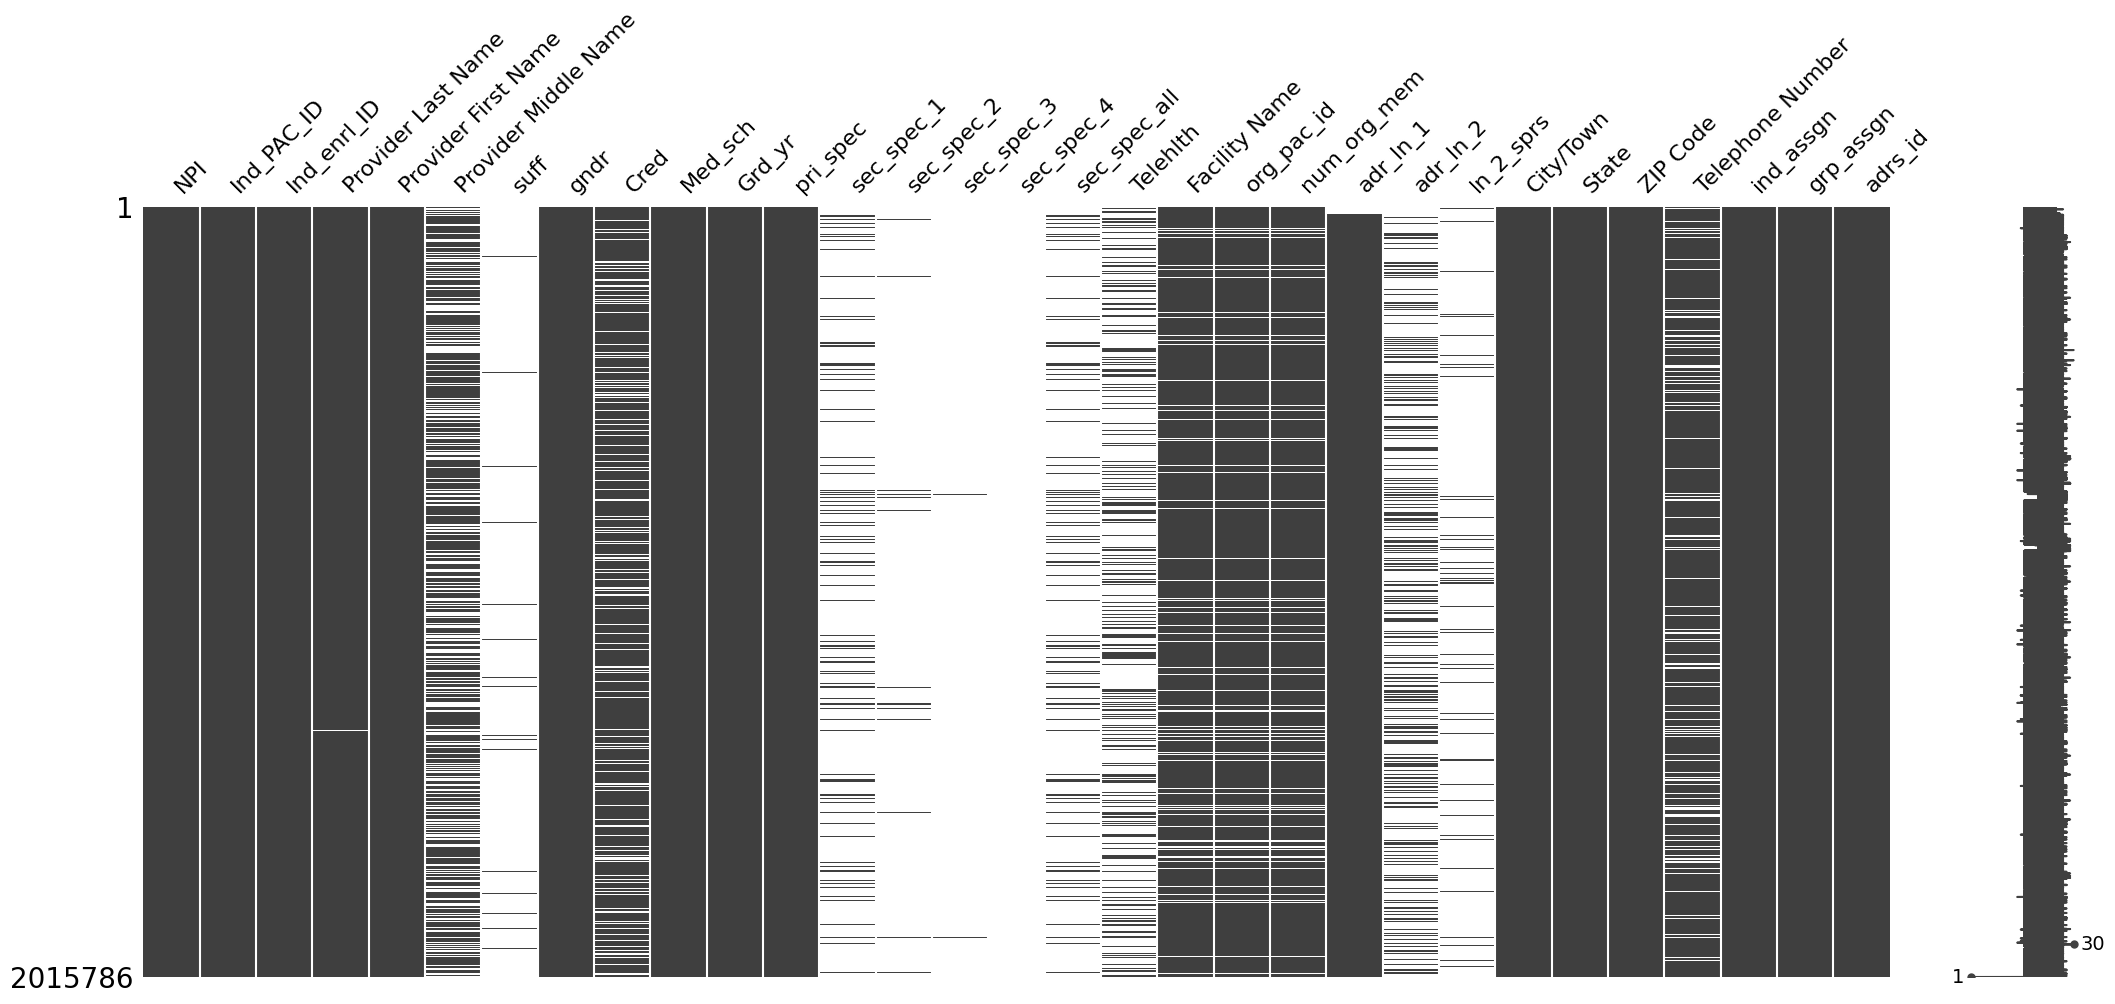

In [13]:
plt.figure(figsize=(12,6))

msno.matrix(df)

plt.show()

In [14]:
duplicates = df[df.duplicated()]

print(
    "Duplicate Rows:",
    len(duplicates)
)

duplicates.to_csv(
    "duplicate_records.csv",
    index=False
)

duplicates.head()

Duplicate Rows: 0


,NPI,Ind_PAC_ID,Ind_enrl_ID,Provider Last Name,Provider First Name,Provider Middle Name,suff,gndr,Cred,Med_sch,Grd_yr,pri_spec,sec_spec_1,sec_spec_2,sec_spec_3,sec_spec_4,sec_spec_all,Telehlth,Facility Name,org_pac_id,num_org_mem,adr_ln_1,adr_ln_2,ln_2_sprs,City/Town,State,ZIP Code,Telephone Number,ind_assgn,grp_assgn,adrs_id


In [15]:
quality_scores=[]

for col in df.columns:

    completeness = (
        1 -
        df[col].isnull().mean()
    ) * 100

    quality_scores.append([

        col,

        round(completeness,2)

    ])

quality = pd.DataFrame(

    quality_scores,

    columns=[

        "column",

        "quality_score"

    ]

)

quality.head()

,column,quality_score
0,NPI,100.0
1,Ind_PAC_ID,100.0
2,Ind_enrl_ID,100.0
3,Provider Last Name,100.0
4,Provider First Name,100.0


In [16]:
text_columns=[]

for c in df.columns:

    if str(df[c].dtype)=="object":

        text_columns.append(c)

print(text_columns)

['Ind_enrl_ID', 'Provider Last Name', 'Provider First Name', 'Provider Middle Name', 'suff', 'gndr', 'Cred', 'Med_sch', 'pri_spec', 'sec_spec_1', 'sec_spec_2', 'sec_spec_3', 'sec_spec_4', 'sec_spec_all', 'Telehlth', 'Facility Name', 'adr_ln_1', 'adr_ln_2', 'ln_2_sprs', 'City/Town', 'State', 'ZIP Code', 'ind_assgn', 'grp_assgn', 'adrs_id']


In [17]:
candidate=None

for c in text_columns:

    if df[c].nunique()>100:

        candidate=c
        break

print("Entity Resolution Column:", candidate)

Entity Resolution Column: Ind_enrl_ID


In [18]:
if candidate is not None:

    sample=(
        df[candidate]
        .astype(str)
        .dropna()
        .drop_duplicates()
        .head(500)
        .tolist()
    )

    matches=[]

    for i in range(len(sample)):

        for j in range(i+1,len(sample)):

            score=fuzz.ratio(

                sample[i],

                sample[j]

            )

            if score>=90:

                matches.append([

                    sample[i],

                    sample[j],

                    score

                ])

    entity=pd.DataFrame(

        matches,

        columns=[

            "record_1",

            "record_2",

            "match_score"

        ]

    )

else:

    entity=pd.DataFrame()

entity.head()

,record_1,record_2,match_score
0,I20220510001310,I20220517001310,93.333333
1,I20240207003290,I20240207002904,93.333333
2,I20050927001472,I20050927001047,93.333333


In [19]:
validation=[]

for col in df.columns:

    uniqueness=round(

        df[col].nunique()/

        len(df),

        4

    )

    validation.append([

        col,

        uniqueness

    ])

validation=pd.DataFrame(

    validation,

    columns=[

        "column",

        "uniqueness_ratio"

    ]

)

validation.head()

,column,uniqueness_ratio
0,NPI,0.5605
1,Ind_PAC_ID,0.5605
2,Ind_enrl_ID,0.5939
3,Provider Last Name,0.1319
4,Provider First Name,0.0434


In [20]:
summary=pd.DataFrame({

    "metric":[

        "rows",

        "columns",

        "duplicates",

        "missing_values",

        "entity_matches"

    ],

    "value":[

        len(df),

        len(df.columns),

        profile["duplicates"],

        profile["missing_values"],

        len(entity)

    ]

})

summary

,metric,value
0,rows,2015786
1,columns,31
2,duplicates,0
3,missing_values,18304070
4,entity_matches,3


In [21]:
quality.to_csv(

    "quality_scorecard.csv",

    index=False

)

validation.to_csv(

    "relationship_validation.csv",

    index=False

)

entity.to_csv(

    "entity_resolution.csv",

    index=False

)

summary.to_csv(

    "quality_summary.csv",

    index=False

)

print("All Outputs Exported")

All Outputs Exported


In [22]:
from google.colab import files

files.download(
    "quality_scorecard.csv"
)

files.download(
    "relationship_validation.csv"
)

files.download(
    "entity_resolution.csv"
)

files.download(
    "quality_summary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>